# Zusätzliche Bewertung


In [54]:
import pandas as pd
import ast
import re

df = pd.read_excel('../data/train/labels/train_val.xlsx')
df.head()

,Image No.,Rating,Cond.,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate,Image_path,Rating_clean,Adhesive,additional_rating
0,Image_00530,5,F,Sikaflex-668 PC,SCP,Plasma 2,NaN,PP,Image_FHNW_00530.jpg,5,[],NaN
1,Image_00621,1,G,Sikaflex-668 PC,SCP,NaN,SP-507,Pulverlack,Image_FHNW_00621.jpg,1,[],NaN
2,Image_00465,1,F,Sikaflex-252,AP-C,NaN,SP-207,Alu roh,Image_FHNW_00465.jpg,1,[],NaN
3,Image_00769,1,L,Sikaflex-268,SCP,NaN,SP-207,Alu,Image_FHNW_00769.jpg,1,[],NaN
4,Image_00561,1,F,Sikaflex-268,SCP,SA-100,NaN,Pulverlack,Image_FHNW_00561.jpg,1,[],NaN


In [55]:
df['Adhesive'].value_counts()

Adhesive
[]                  729
['SCPrF', '10%']      7
['ES', '5%']          6
['SCF', '60%']        6
['ES', '10%']         4
['PaIF', '5%']        4
['ES', '20%']         4
['SCF', '30%']        4
['SCF', '50%']        3
['SCF']               3
['PaIF']              3
['PaIF', '15%']       2
['CFPa', '60%']       2
['SCPrF30%']          2
['SF', '10%']         2
['SCF', '40%']        2
['ES', '30%']         2
['PaIF', '30%']       1
['TU', '60%']         1
['TU', '20%']         1
['PaIF', '25%']       1
['SCF', '75%']        1
['SCF', '10%']        1
['ES', '15%']         1
['PaDF', '<5%']       1
['SCPrF40%']          1
['SCF', '80%']        1
['PaIF', '10%']       1
['SCF', '20%']        1
['SF', '50%']         1
['PaIF', '85%']       1
['TU', '25%']         1
['SCPrF', '25%']      1
['TU', '50%']         1
['ES', '40%']         1
['SF', '15%']         1
['SCF', '70%']        1
['SCPrF', '5%']       1
Name: count, dtype: int64

## Unterscheiden zwischen Fehler und Prozentzahl

In [56]:
def extract_first(s):
    if not isinstance(s, str) or not s.strip():
        return None
    try:
        lst = ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return None
    if not isinstance(lst, list) or not lst:
        return None

    first = lst[0]

    cleaned = re.sub(r'[^A-Za-z]', '', first)

    return cleaned or None

df['additional_rating'] = df['Adhesive'].apply(extract_first)
df.head()

,Image No.,Rating,Cond.,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate,Image_path,Rating_clean,Adhesive,additional_rating
0,Image_00530,5,F,Sikaflex-668 PC,SCP,Plasma 2,NaN,PP,Image_FHNW_00530.jpg,5,[],None
1,Image_00621,1,G,Sikaflex-668 PC,SCP,NaN,SP-507,Pulverlack,Image_FHNW_00621.jpg,1,[],None
2,Image_00465,1,F,Sikaflex-252,AP-C,NaN,SP-207,Alu roh,Image_FHNW_00465.jpg,1,[],None
3,Image_00769,1,L,Sikaflex-268,SCP,NaN,SP-207,Alu,Image_FHNW_00769.jpg,1,[],None
4,Image_00561,1,F,Sikaflex-268,SCP,SA-100,NaN,Pulverlack,Image_FHNW_00561.jpg,1,[],None


In [57]:
df['additional_rating'].value_counts()

additional_rating
SCF      23
ES       18
PaIF     13
SCPrF    12
TU        4
SF        4
CFPa      2
PaDF      1
Name: count, dtype: int64

## Bedeutung der zusätzlichen Bewertung
**Bewertungen für Sika-Produkte:**

| Kürzel | Englisch                         | Beschreibung                                                                 |
|--------|----------------------------------|------------------------------------------------------------------------------|
| TU     | Tunnel effect / edge bonding     | In der Mitte des Klebstreifens hat es keinen Klebstoff                      |
| NC     | Not cured                        | Der Klebstoff ist nicht vollständig getrocknet                              |
| SCF    | Special cohesion failure         | Kohäsionsversagen nahe am Substrat (Substrat sichtbar)                      |
| FS     | Foam structure                   | Schaumstruktur in der Klebezone                                             |
| BFB    | Bubbles in bulk                  | Blasen im Klebstoffkörper                                                   |
| ES     | Edge separation                  | Randablösung                                                                |
| SCPrF  | Adhesive failure @ primer/substr.| Haftversagen zwischen Primer und Substrat                                   |
| CPrF   | Cohesive failure in primer       | Kohäsionsversagen im Primer                                                 |
| BF     | Bead tear-off w/o prior peeling  | Klebstoffrausreißen ohne vorheriges Ablösen                                 |
| NT     | Not tested                       | Nicht geprüft                                                               |

**Bewertung für Substrate:**

| Kürzel | Englisch                           | Beschreibung                                                              |
|--------|------------------------------------|---------------------------------------------------------------------------|
| BS     | Bubbles / voids on substrate       | Blasen oder Hohlräume auf der Substratoberfläche                          |
| SF     | Substrate failure                  | Versagen im Substrat (z. B. in Fasern oder Schichten nicht beschichteter Substrate) |
| CFPa   | Cohesive failure in paint          | Kohäsionsversagen in der Lackschicht                                      |
| PaIF   | Rupture between paint layers       | Riss zwischen verschiedenen Lackschichten                                 |
| PaDF   | Rupture of paint                   | Abtrennung der Lackschicht vom festen Substrat                            |
| Cor    | Corrosion of the base material     | Korrosion des Grundmaterials                                              |







## Beispiel pro Bewertung

In [58]:
import cv2
import os

image_path = "../data/train/img"
image_files = [f for f in os.listdir(image_path) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Bilder als (Dateiname, Bild) Tupel einlesen
images_with_names = [(file, img) for file in image_files if (img := cv2.imread(os.path.join(image_path, file))) is not None]

ignored_files = set(image_files) - {name for name, _ in images_with_names}
if ignored_files:
    print("Folgende Dateien konnten nicht geladen werden:", ignored_files)

In [59]:
import matplotlib.pyplot as plt
import math


df.groupby('additional_rating')

df_filtered = df.groupby('additional_rating').first().reset_index()
df_filtered

,additional_rating,Image No.,Rating,Cond.,Product,Pre-treatment 1,Pre-treatment 2,Pre-treatment 3,Substrate,Image_path,Rating_clean,Adhesive
0,CFPa,Image_00848,3 CFPa 60%,L,Sikaflex-268,SCP,SA-100,SP-207,GFK,Image_FHNW_00848.jpg,3,"['CFPa', '60%']"
1,ES,Image_00626,2 ES 5%,G,Sikaflex-268,SCP,SA-100,None,Pulverlack,Image_FHNW_00626.jpg,2,"['ES', '5%']"
2,PaDF,Image_00414,1 PaDF <5%,C,Sikaflex-271 PC,SCP,None,SP-207,Paint,Image_FHNW_00414.jpg,1,"['PaDF', '<5%']"
3,PaIF,Image_00949,2 PaIF 15%,F,Sikaflex-668,SCP,SA-100,SP-507,Decklack,Image_FHNW_00949.jpg,2,"['PaIF', '15%']"
4,SCF,Image_00287,3 SCF 60%,L,Sikaflex-554 PC,SCP,SA-205,None,Alu,Image_FHNW_00287.jpg,3,"['SCF', '60%']"
5,SCPrF,Image_00526,2 SCPrF 10%,L,Sikaflex-668 PC,SCP,Plasma 1,SP-507,PP,Image_FHNW_00526.jpg,2,"['SCPrF', '10%']"
6,SF,Image_01000,2 SF 10%,F,Sikaflex-521 UV,SCP,SA-205,SP-207,GFK,Image_FHNW_01000.jpg,2,"['SF', '10%']"
7,TU,Image_00218,2 TU 20%,C,Sikaflex-554 PC,SCP,SA-205,None,PVC,Image_FHNW_00218.jpg,2,"['TU', '20%']"


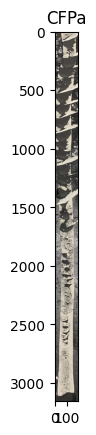

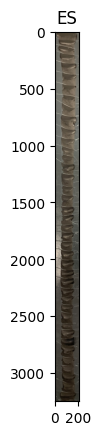

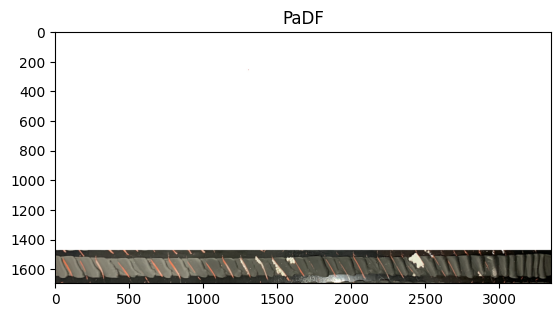

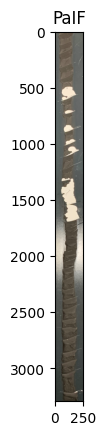

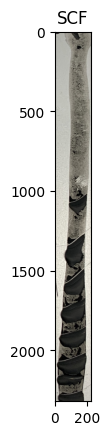

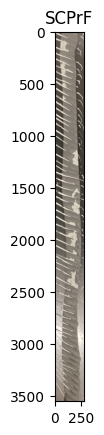

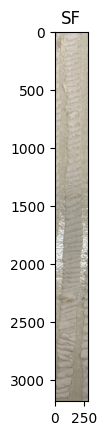

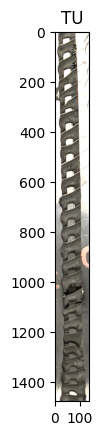

In [60]:
for i, row in df_filtered.iterrows():
    image_name = row['Image_path']
    image = next((img for name, img in images_with_names if name == image_name), None)
    
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(row['additional_rating'])
    plt.show()

In [61]:
list_of_labels = df['additional_rating'].tolist()

In [62]:
counts_of_labels = pd.Series(list_of_labels).value_counts()
counts_of_labels

SCF      23
ES       18
PaIF     13
SCPrF    12
TU        4
SF        4
CFPa      2
PaDF      1
Name: count, dtype: int64